1. Import Library dan Load Dataset

In [ ]:
# ======================================
# 1. Import Library
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# ======================================
# 2. Load Dataset
# ======================================
# Pastikan nama file sesuai dengan yang kamu upload
df = pd.read_csv('Mall_Customers.csv')

# Tampilkan 5 data pertama
print("===== DATASET AWAL =====")
print(df.head())

# Info dataset
print("\n===== INFORMASI DATASET =====")
print(df.info())


===== DATASET AWAL =====
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

===== INFORMASI DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


2. Pemeriksaan Awal Data

In [ ]:
# Melihat statistik umum
print("\n===== STATISTIK DESKRIPTIF =====")
print(df.describe())

# Mengecek nilai kosong
print("\n===== CEK NILAI KOSONG =====")
print(df.isnull().sum())

# Melihat jumlah data duplikat
print("\nJumlah data duplikat:", df.duplicated().sum())



===== STATISTIK DESKRIPTIF =====
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

===== CEK NILAI KOSONG =====
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Jumlah data duplikat: 0


3. Membersihkan dan Menyiapkan Data

In [ ]:
# Ubah nama kolom agar mudah diolah
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

# Hapus kolom CustomerID karena tidak relevan untuk analisis
df.drop('CustomerID', axis=1, inplace=True)

# Encode kolom Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

print("\n===== DATASET SETELAH ENCODING =====")
print(df.head())



===== DATASET SETELAH ENCODING =====
   Gender  Age  Annual_Income  Spending_Score
0       1   19             15              39
1       1   21             15              81
2       0   20             16               6
3       0   23             16              77
4       0   31             17              40


4. Normalisasi Data Numerik

In [ ]:


# Buat objek scaler
scaler = MinMaxScaler()

# Pilih kolom numerik untuk dinormalisasi
num_cols = ['Age', 'Annual_Income', 'Spending_Score']

# Lakukan normalisasi
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\n===== DATASET SETELAH NORMALISASI =====")
print(df.head())



===== DATASET SETELAH NORMALISASI =====
   Gender       Age  Annual_Income  Spending_Score
0       1  0.019231       0.000000        0.387755
1       1  0.057692       0.000000        0.816327
2       0  0.038462       0.008197        0.051020
3       0  0.096154       0.008197        0.775510
4       0  0.250000       0.016393        0.397959


5. Visualisasi Data Setelah Preprocessing

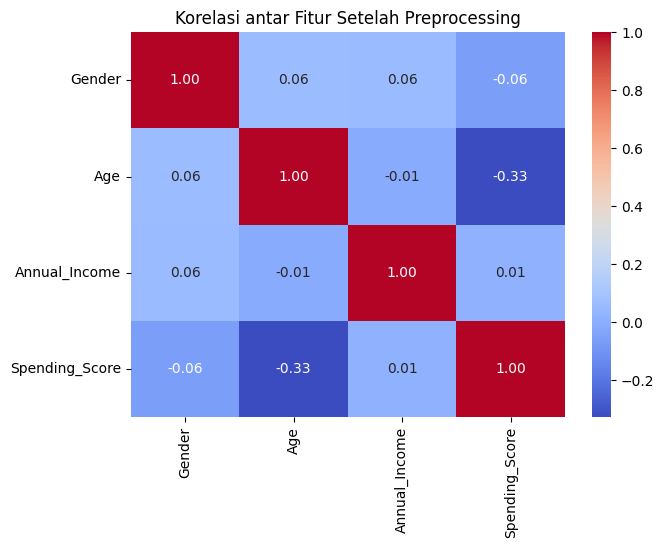

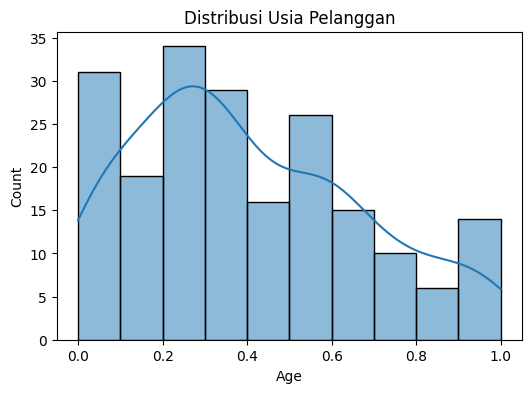

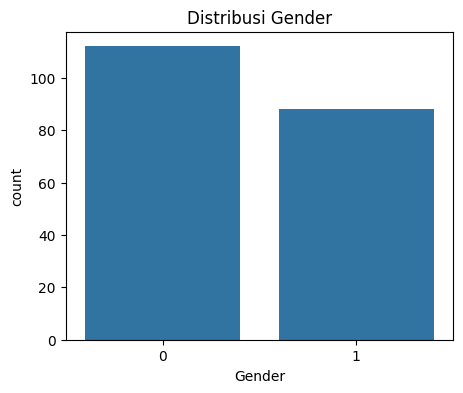

In [ ]:
# Korelasi antar fitur
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi antar Fitur Setelah Preprocessing")
plt.show()

# Distribusi usia
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Distribusi Usia Pelanggan")
plt.show()

# Perbandingan Gender
plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=df)
plt.title("Distribusi Gender")
plt.show()


6. Simpan Dataset Hasil Preprocessing

In [ ]:
# Simpan hasil preprocessing ke file baru
df.to_csv('mall_customers_clean.csv', index=False)
print(" Dataset hasil preprocessing disimpan sebagai 'mall_customers_clean.csv'")


 Dataset hasil preprocessing disimpan sebagai 'mall_customers_clean.csv'
